# Adult Income Analysis Experiments

This notebook runs the full Adult Income analysis from data loading to the final comparison tables. The reusable logic stays in `src/`, while the notebook writes the same `csv` and `png` artifacts to `outputs/`.


In [1]:
from __future__ import annotations

import ast
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import mutual_info_score

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import config
from src.utils import ensure_project_directories, save_dataframe
from src.data_loader import build_data_dictionary, load_standardized_data
from src.preprocess import build_analysis_dataframe, retained_features_table
from src.split import apply_split, load_or_create_split
from src.eda import (
    categorical_frequency_summary,
    class_balance_table,
    continuous_feature_summary,
    continuous_flag_table,
    plot_categorical_frequency_grid,
    plot_class_balance,
    plot_continuous_by_income,
)
from src.distribution_analysis import (
    gaussian_fit_summary,
    plot_continuous_separation_ranking,
    plot_gaussian_overlays,
)
from src.mi_analysis import (
    apply_binning_rules,
    compute_mi_outputs,
    fit_binning_rules,
    plot_feature_label_ranking,
    plot_mi_heatmap,
    plot_top_pairs,
    select_candidate_interactions,
    mi_sensitivity_overlap,
)
from src.logistic_signal import (
    choose_best_c,
    cross_validate_logistic,
    evaluate_logistic_model,
    fit_logistic_and_extract_coefficients,
    plot_coefficient_paths,
    feature_group_stability_table,
)
from src.interaction_validation import (
    evaluate_interaction_candidates,
    interaction_model_metrics_table,
    plot_interaction_delta_auc,
)
from src.svm_boundary import (
    build_final_model_comparison,
    plot_svm_kernel_comparison,
    tune_and_evaluate_svm_models,
)
from src.robustness import plot_robustness_ranges, run_robustness_checks

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

ensure_project_directories()


def show_table(df: pd.DataFrame, rows: int = 5) -> None:
    display(df.head(rows))


def show_image(path: Path) -> None:
    display(Image(filename=str(path)))


## Data Setup

We start by loading the standardized data, building the analysis dataframe, and recreating the fixed train/test split used throughout the rest of the notebook.


In [2]:
standardized_df = load_standardized_data()
analysis_df = build_analysis_dataframe(standardized_df)
manifest = load_or_create_split(analysis_df, config.MAIN_SPLIT_SEED)
train_df, test_df = apply_split(analysis_df, manifest)

print(f"standardized rows: {len(standardized_df):,}")
print(f"analysis rows: {len(analysis_df):,}")
print(f"train rows: {len(train_df):,}")
print(f"test rows: {len(test_df):,}")
show_table(analysis_df)


standardized rows: 48,842
analysis rows: 48,842
train rows: 39,073
test rows: 9,769


,row_id,age,workclass,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income_gt_50k,native_country_grouped,capital_gain_log1p,capital_loss_log1p
0,0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,United-States,0.000000,0.0
1,1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,United-States,0.000000,0.0
2,2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,United-States,0.000000,0.0
3,3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,United-States,8.947546,0.0
4,4,18,?,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,0,United-States,0.000000,0.0


## Audit

Before getting into results, this section records the schema, checks how missing values appear in practice, lists the retained features, and documents the grouped `native_country` decision.


In [3]:

data_dictionary_df = build_data_dictionary(standardized_df)
save_dataframe(data_dictionary_df, config.TABLES_DIR / "data_dictionary.csv")

retained_df = retained_features_table()
save_dataframe(retained_df, config.TABLES_DIR / "retained_features.csv")

missing_summary_df = (
    standardized_df.isna()
    .sum()
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing_summary_df["missing_share"] = missing_summary_df["missing_count"] / len(standardized_df)
save_dataframe(missing_summary_df, config.TABLES_DIR / "missing_value_summary.csv")

native_country_raw = standardized_df["native_country"].fillna("Missing")
native_country_grouped = analysis_df["native_country_grouped"]
raw_mi = mutual_info_score(native_country_raw, analysis_df[config.LABEL_COLUMN])
grouped_mi = mutual_info_score(native_country_grouped, analysis_df[config.LABEL_COLUMN])
us_share = float((native_country_raw == "United-States").mean())

native_country_df = (
    native_country_grouped.value_counts(normalize=False)
    .rename_axis("native_country_grouped")
    .reset_index(name="count")
)
native_country_df["share"] = native_country_df["count"] / len(analysis_df)
native_country_df["raw_mi_with_label"] = raw_mi
native_country_df["grouped_mi_with_label"] = grouped_mi
save_dataframe(native_country_df, config.TABLES_DIR / "native_country_relevance.csv")

audit_summary_df = pd.DataFrame(
    [
        {"metric": "main_split_seed", "value": config.MAIN_SPLIT_SEED},
        {"metric": "main_split_manifest", "value": f"data/processed/splits/split_seed_{config.MAIN_SPLIT_SEED}.json"},
        {"metric": "native_country_us_share", "value": us_share},
        {"metric": "native_country_raw_mi", "value": raw_mi},
        {"metric": "native_country_grouped_mi", "value": grouped_mi},
    ]
)
save_dataframe(audit_summary_df, config.TABLES_DIR / "audit_summary.csv")

show_table(audit_summary_df, rows=len(audit_summary_df))
show_table(data_dictionary_df)
show_table(missing_summary_df)
show_table(native_country_df)


,metric,value
0,main_split_seed,42
1,main_split_manifest,data/processed/splits/split_seed_42.json
2,native_country_us_share,0.897424
3,native_country_raw_mi,0.005682
4,native_country_grouped_mi,0.00055


,column,dtype,non_null_count,missing_count,nunique,example_values
0,row_id,int64,48842,0,48842,0 | 1 | 2 | 3 | 4
1,age,int64,48842,0,74,25 | 38 | 28 | 44 | 18
2,workclass,str,48842,0,9,Private | Private | Local-gov | Private | ?
3,fnlwgt,int64,48842,0,28523,226802 | 89814 | 336951 | 160323 | 103497
4,education,str,48842,0,16,11th | HS-grad | Assoc-acdm | Some-college | S...


,column,missing_count,missing_share
0,row_id,0,0.0
1,age,0,0.0
2,workclass,0,0.0
3,fnlwgt,0,0.0
4,education,0,0.0


,native_country_grouped,count,share,raw_mi_with_label,grouped_mi_with_label
0,United-States,43832,0.897424,0.005682,0.00055
1,Non-United-States,5010,0.102576,0.005682,0.00055


## Focused EDA

This is a quick pass over the training split: class balance first, then the main patterns in the continuous and categorical features that are worth keeping in mind for later modeling.


,income_class,count,proportion
0,<=50K,29724,0.76073
1,>50K,9349,0.23927


,feature,skewness,zero_share,dominant_value_share,flag_code
4,hours_per_week,0.250936,0.000000,0.465232,dominant_value
1,education_num,-0.313872,0.000000,0.324751,none
0,age,0.549670,0.000000,0.027205,none
3,capital_loss,4.497171,0.952090,0.952090,zero_inflated
2,capital_gain,12.047716,0.918256,0.918256,zero_inflated


,income_class,age_mean,age_std,age_median,age_min,age_max,education_num_mean,education_num_std,education_num_median,education_num_min,education_num_max,capital_gain_mean,capital_gain_std,capital_gain_median,capital_gain_min,capital_gain_max,capital_loss_mean,capital_loss_std,capital_loss_median,capital_loss_min,capital_loss_max,hours_per_week_mean,hours_per_week_std,hours_per_week_median,hours_per_week_min,hours_per_week_max
0,<=50K,36.919190,14.138617,34.0,17,90,9.600020,2.442004,9.0,1,16,147.696373,976.203388,0.0,0,41310,55.346252,316.829756,0.0,0,4356,38.891502,12.367231,40.0,1,99
1,>50K,44.350091,10.557660,44.0,19,90,11.602952,2.382411,12.0,1,16,3949.977966,14515.361282,0.0,0,99999,199.977859,602.340502,0.0,0,3683,45.434378,11.201050,40.0,1,99


,feature,category,count,share,positive_rate
37,gender,Male,26140,0.669004,0.303787
38,gender,Female,12933,0.330996,0.108869
24,marital_status,Married-civ-spouse,17842,0.456632,0.448324
25,marital_status,Never-married,12931,0.330945,0.044235
26,marital_status,Divorced,5307,0.135823,0.100433
27,marital_status,Separated,1238,0.031684,0.067044
28,marital_status,Widowed,1221,0.031249,0.087633
29,marital_status,Married-spouse-absent,504,0.012899,0.087302
30,marital_status,Married-AF-spouse,30,0.000768,0.366667
39,native_country_grouped,United-States,35101,0.898344,0.244124


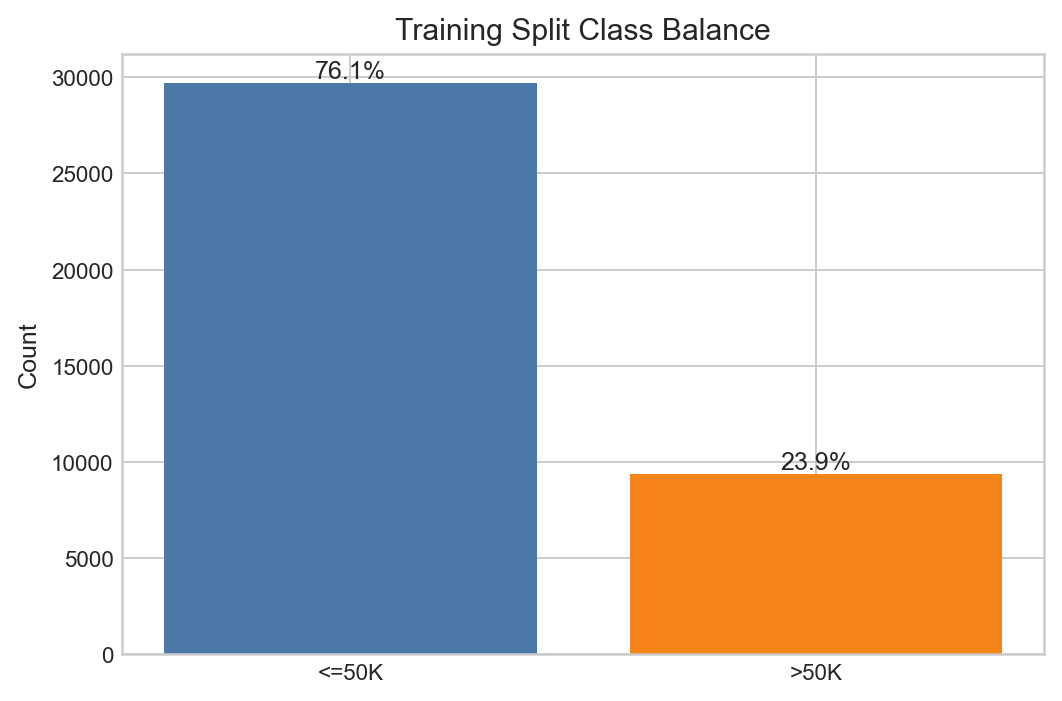

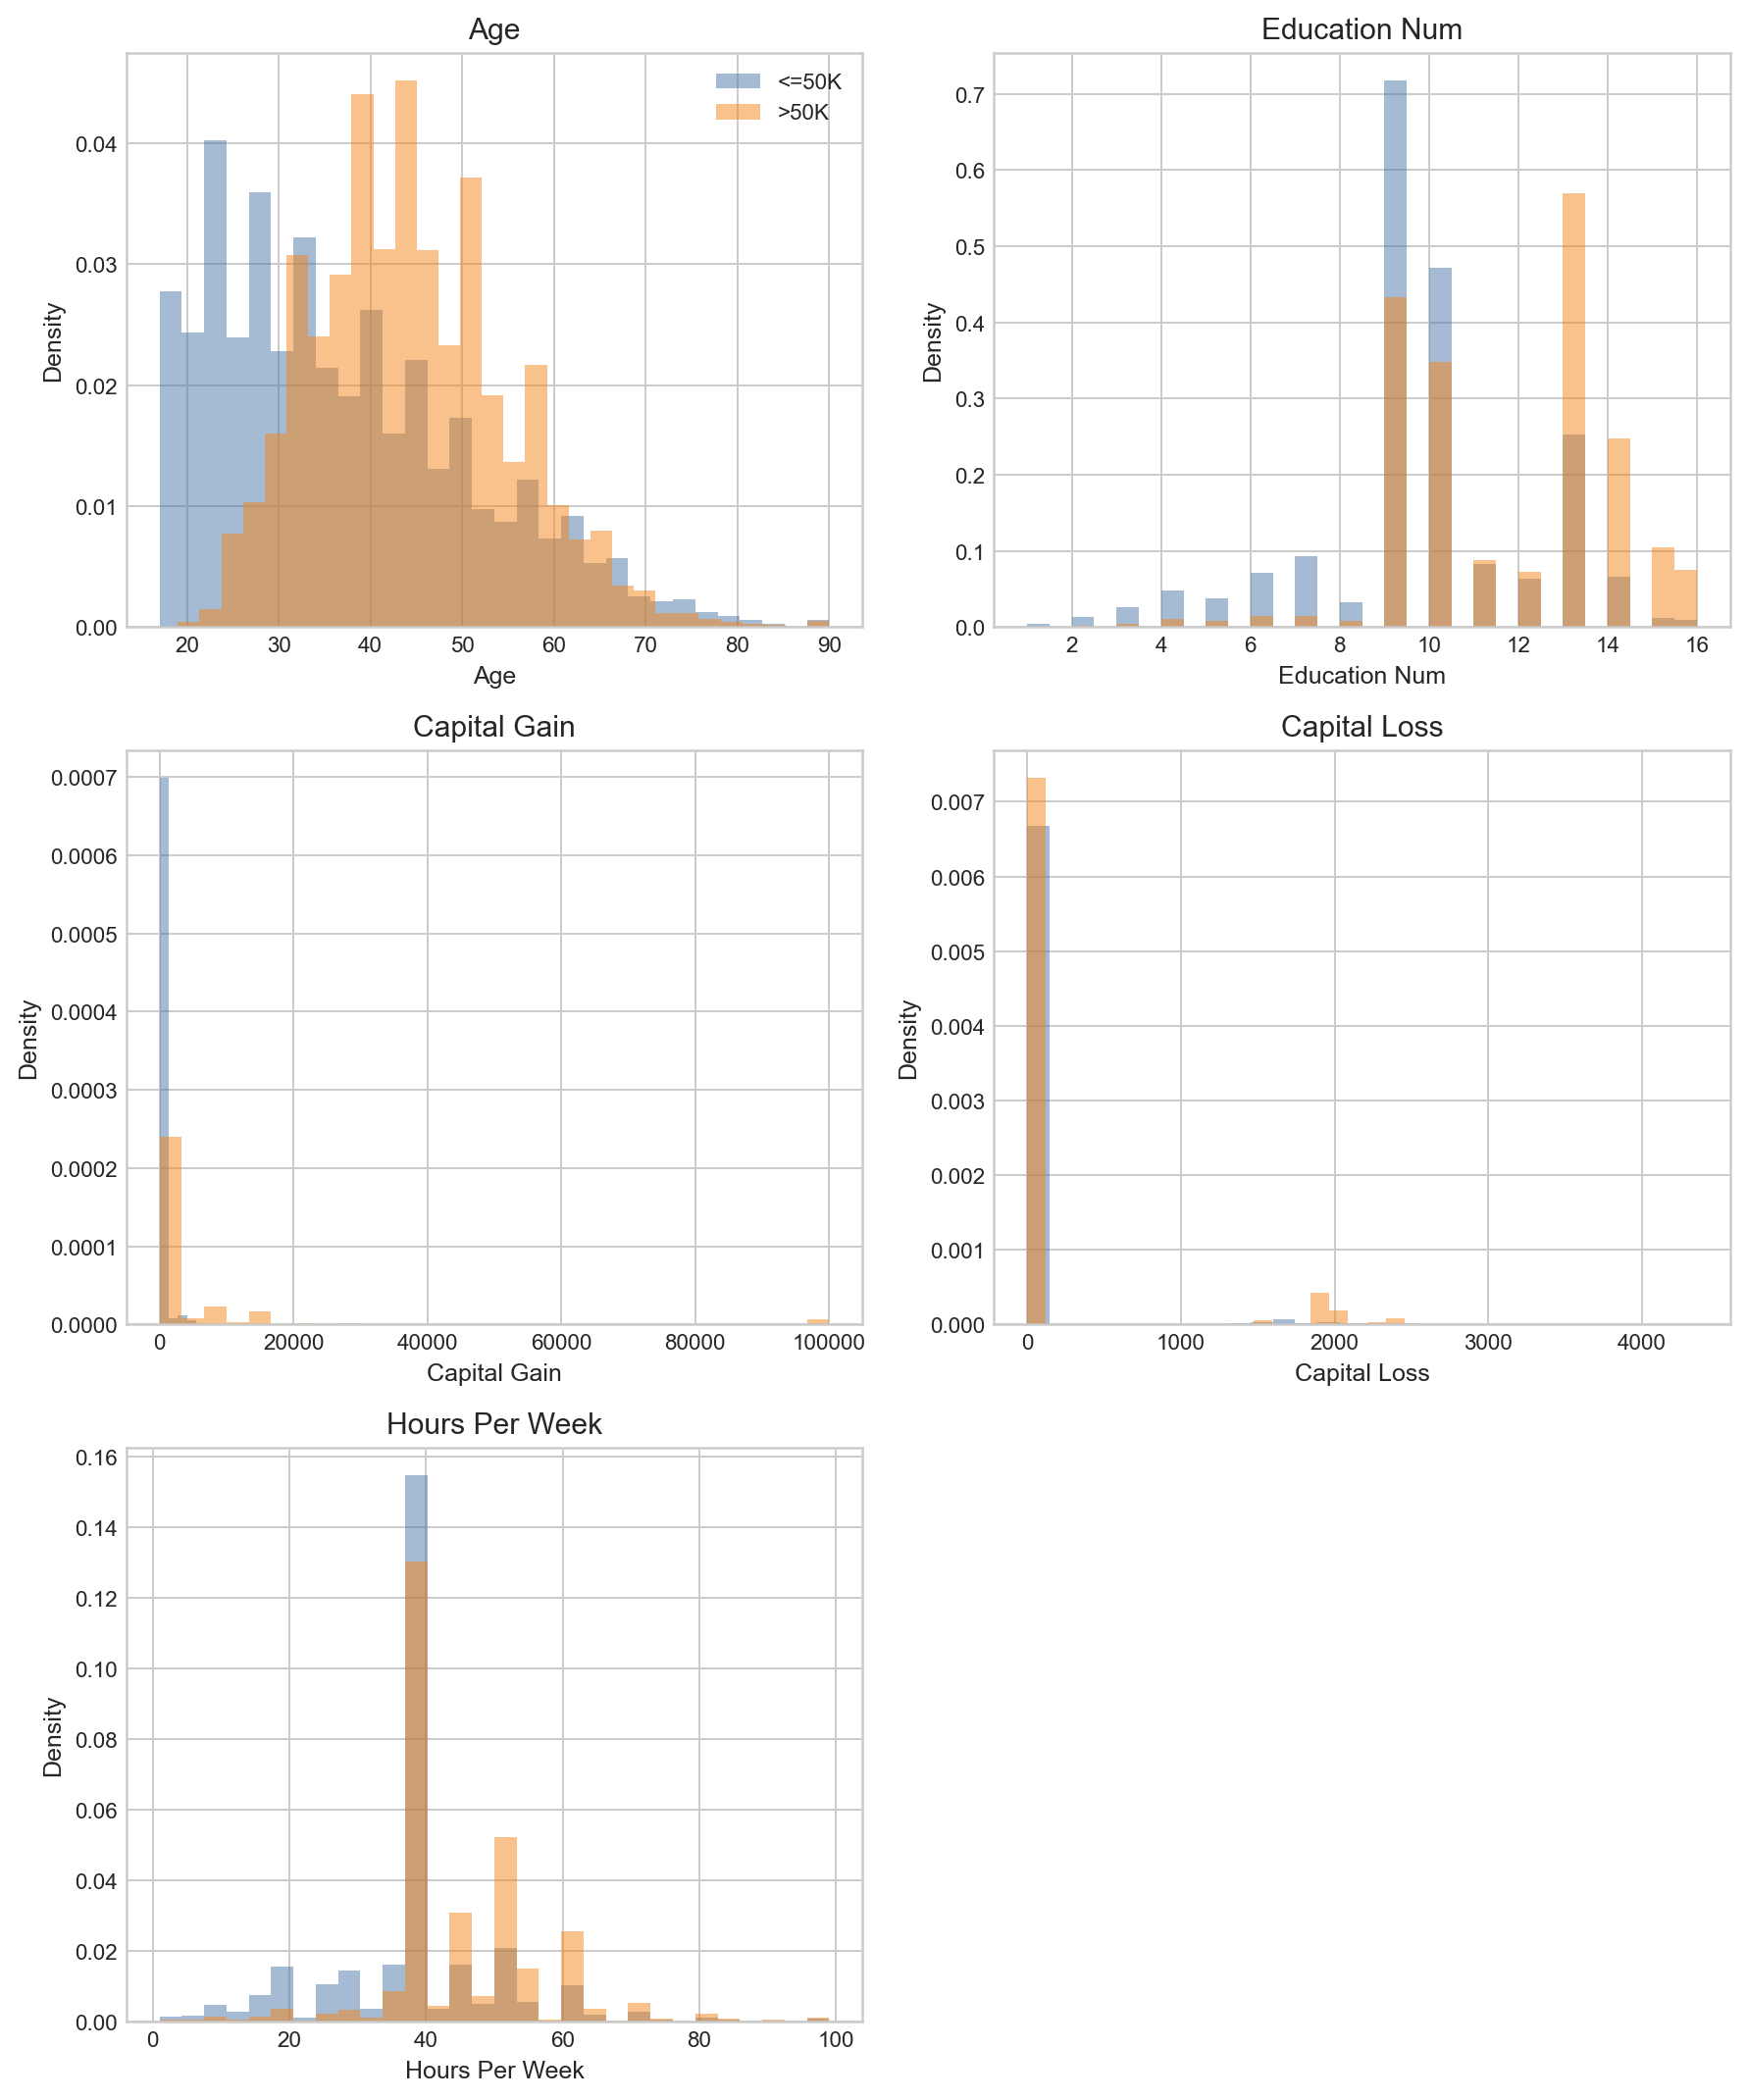

In [4]:
class_balance_df = class_balance_table(train_df)
continuous_summary_df = continuous_feature_summary(train_df)
categorical_summary_df = categorical_frequency_summary(train_df)

save_dataframe(class_balance_df, config.TABLES_DIR / "class_balance_summary.csv")
save_dataframe(continuous_summary_df, config.TABLES_DIR / "continuous_feature_summary.csv")
save_dataframe(categorical_summary_df, config.TABLES_DIR / "categorical_frequency_summary.csv")

plot_class_balance(class_balance_df, config.FIGURES_DIR / "class_balance.png")
plot_continuous_by_income(train_df, config.FIGURES_DIR / "continuous_by_income_grid.png")
plot_categorical_frequency_grid(categorical_summary_df, config.FIGURES_DIR / "categorical_frequency_grid.png")


continuous_flags_df = continuous_flag_table(train_df)
save_dataframe(continuous_flags_df, config.TABLES_DIR / "continuous_feature_flags.csv")

show_table(class_balance_df)
show_table(continuous_flags_df, rows=len(continuous_flags_df))
show_table(continuous_summary_df)
show_table(categorical_summary_df, rows=10)
show_image(config.FIGURES_DIR / "class_balance.png")
show_image(config.FIGURES_DIR / "continuous_by_income_grid.png")
show_image(config.FIGURES_DIR / "categorical_frequency_grid.png")


## Distribution Analysis

Here we look more closely at the continuous variables and ask how much each one separates the two income classes on its own.


,feature,mean_<=50k,variance_<=50k,mean_>50k,variance_>50k,mean_difference_gt50k_minus_le50k,cohens_d,ks_statistic,single_feature_roc_auc,zero_share,skewness,non_gaussian_flag,shape_category
0,education_num,9.600020,5.963183,11.602952,5.675276e+00,2.002932,0.824972,0.335590,0.715573,0.000000,-0.313872,False,roughly_symmetric
1,age,36.919190,199.893752,44.350091,1.114523e+02,7.430901,0.555813,0.320961,0.682310,0.000000,0.549670,False,roughly_symmetric
2,hours_per_week,38.891502,152.943248,45.434378,1.254501e+02,6.542876,0.540803,0.261334,0.671324,0.000000,0.250936,False,roughly_symmetric
3,capital_gain,147.696373,952940.993566,3949.977966,2.106732e+08,3802.281592,0.531721,0.187844,0.588260,0.918256,12.047716,True,non_gaussian_weak
4,capital_loss,55.346252,100377.717076,199.977859,3.627753e+05,144.631606,0.358050,0.081222,0.535493,0.952090,4.497171,True,non_gaussian_weak


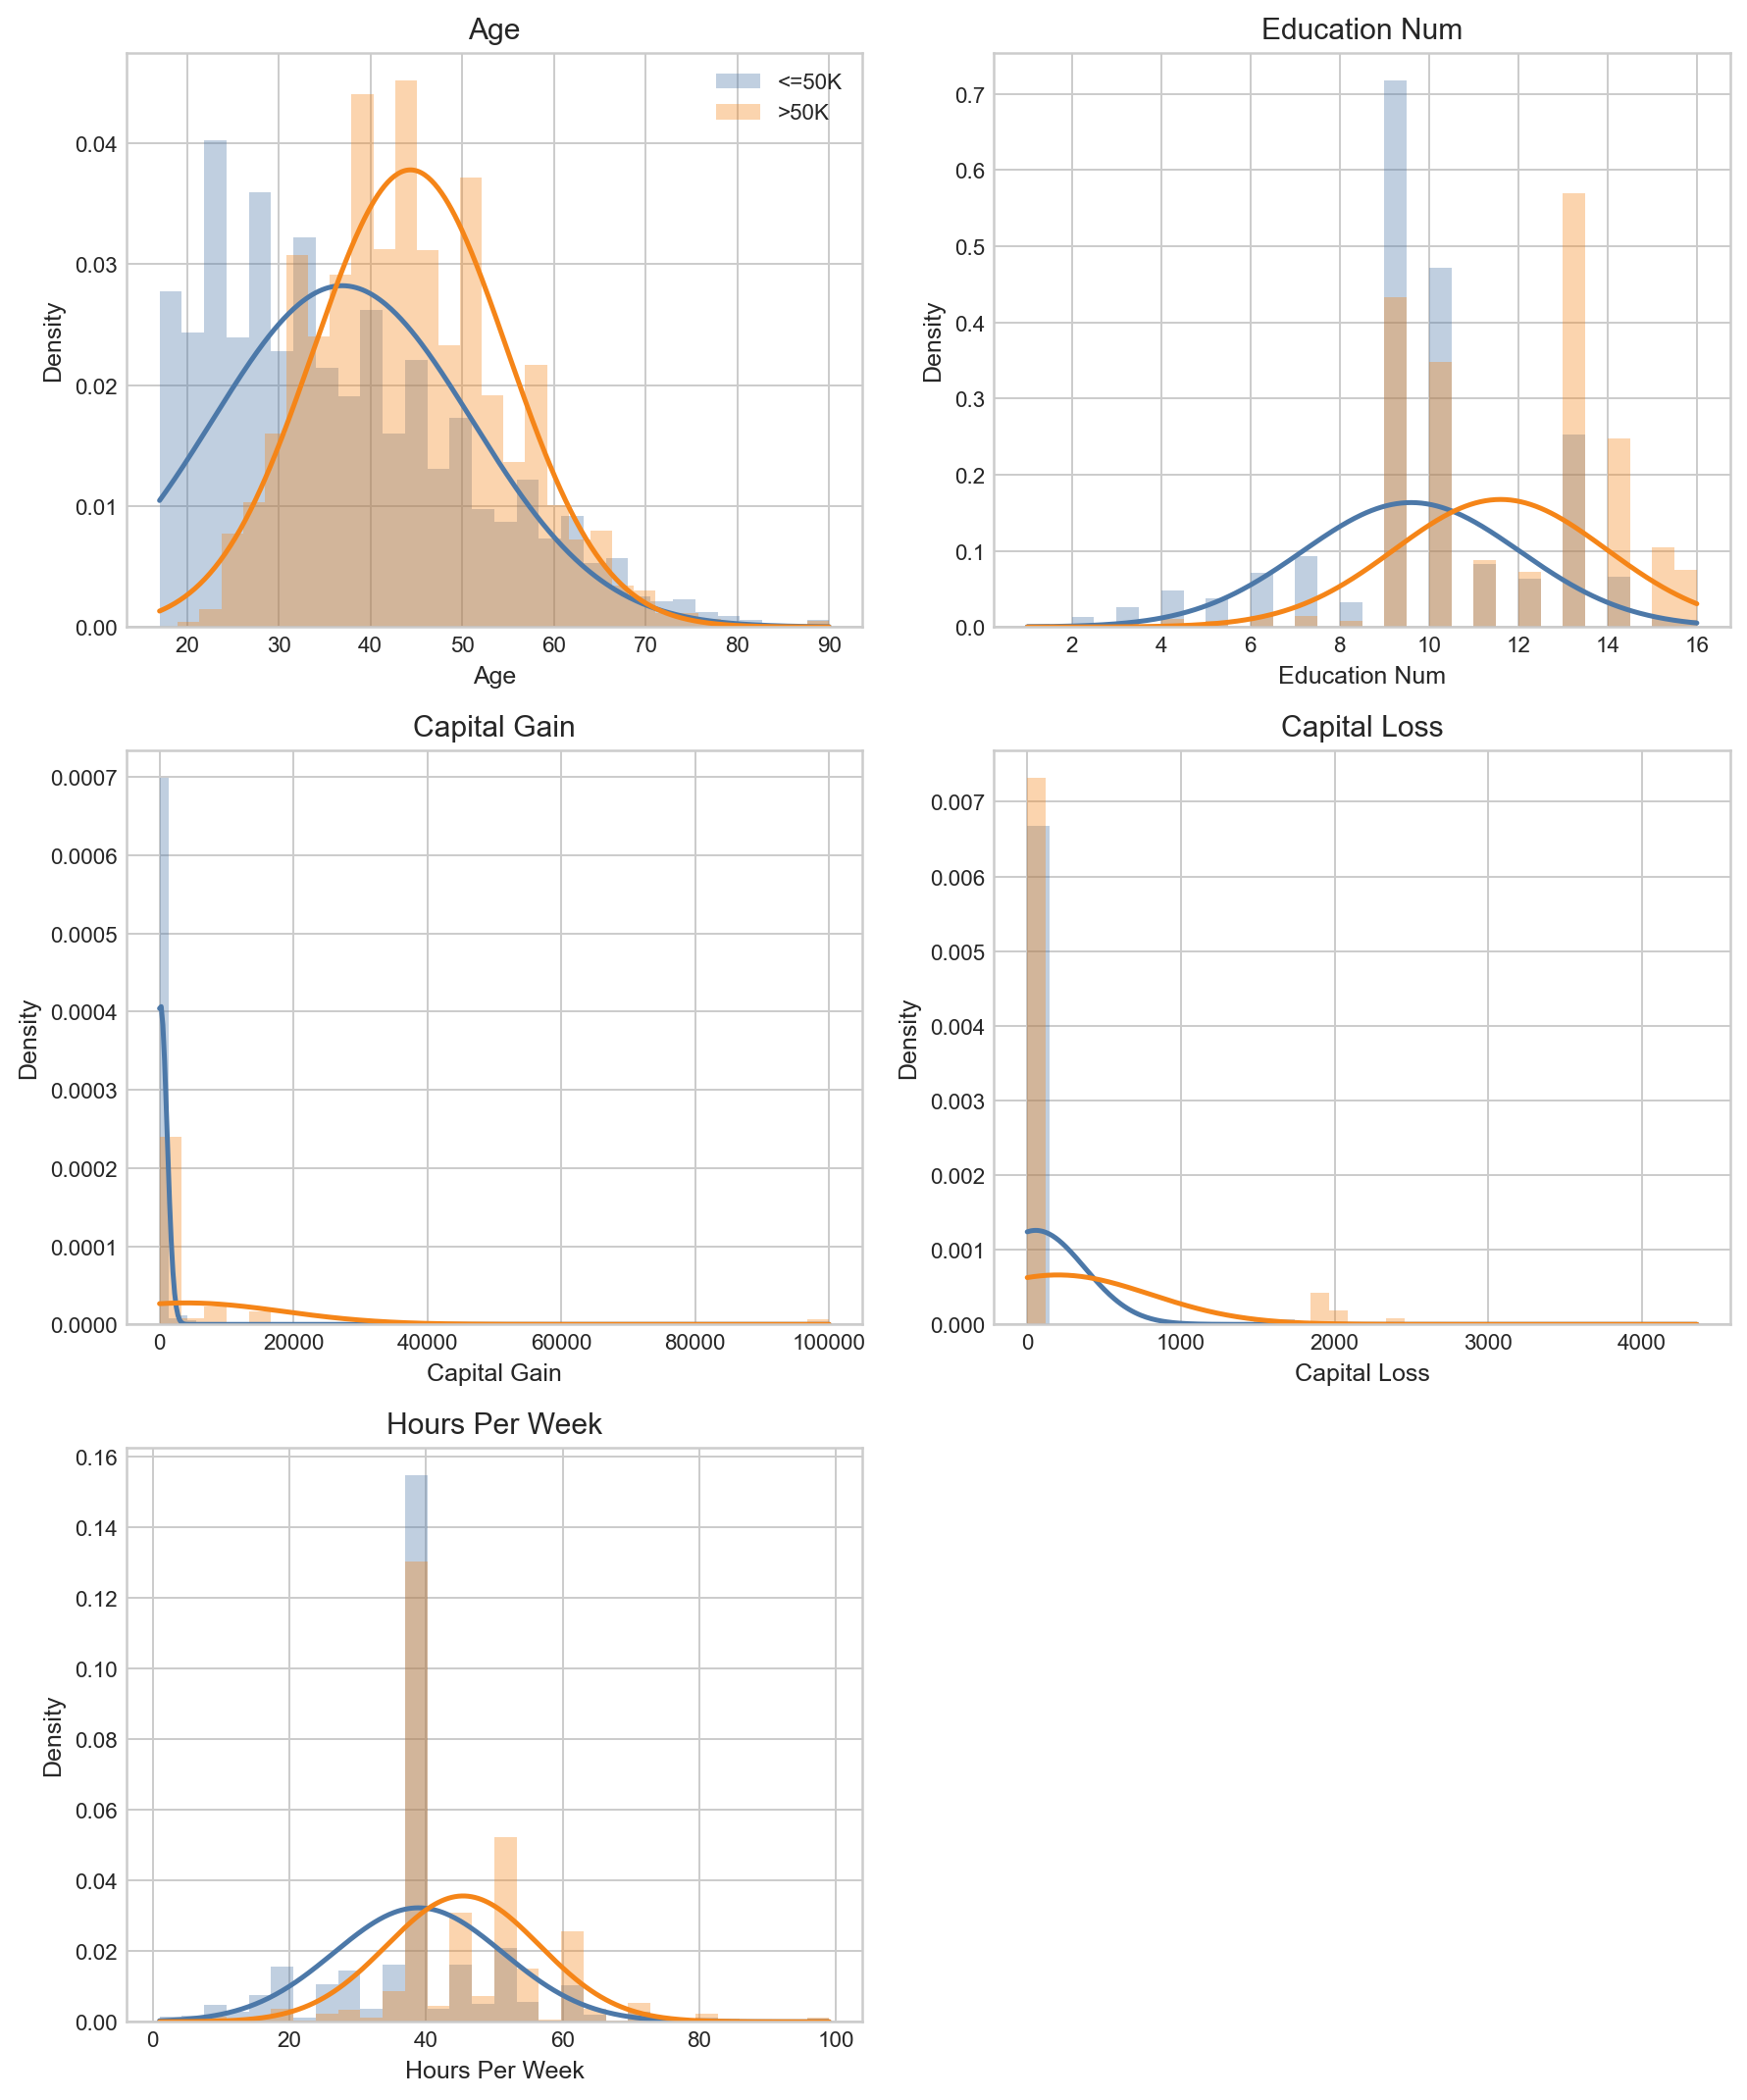

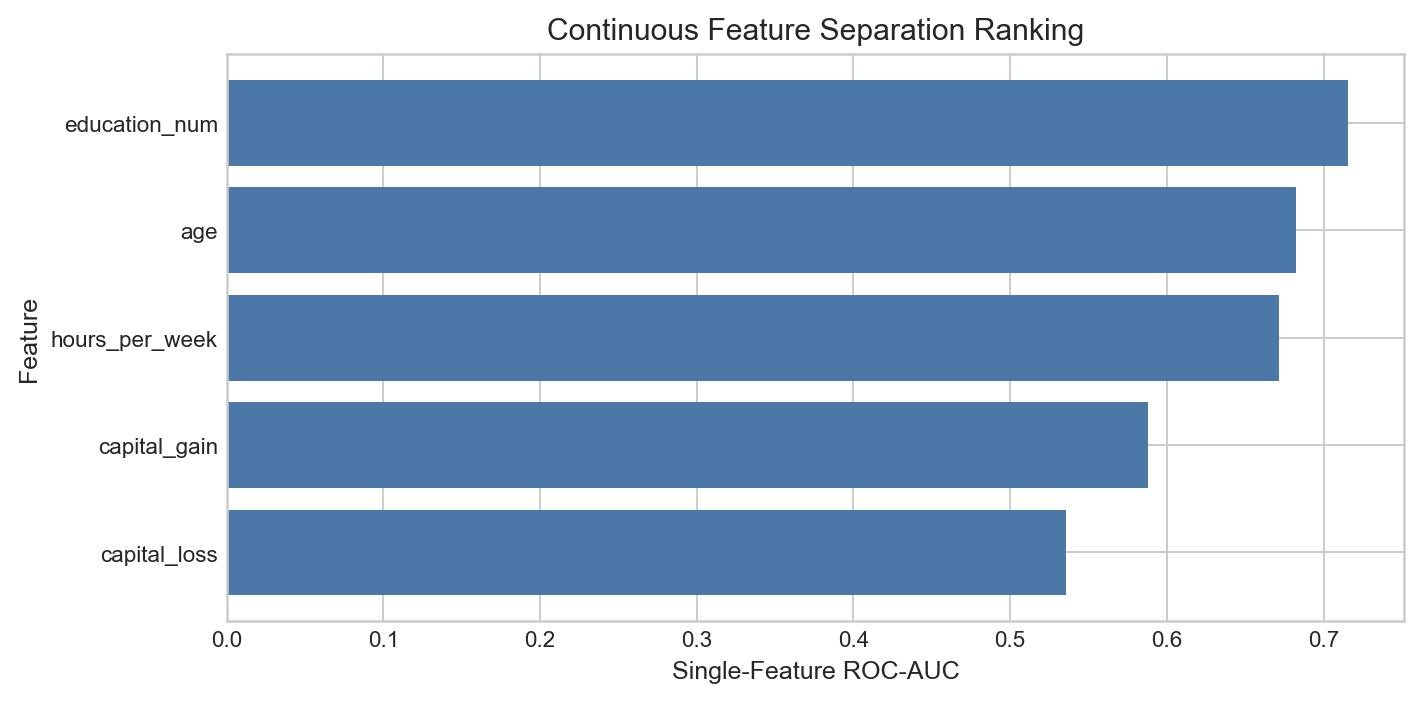

In [5]:
gaussian_df = gaussian_fit_summary(train_df)
ranked_df = gaussian_df.sort_values("single_feature_roc_auc", ascending=False).reset_index(drop=True)

save_dataframe(gaussian_df, config.TABLES_DIR / "gaussian_fit_summary.csv")
save_dataframe(ranked_df, config.TABLES_DIR / "ranked_continuous_features.csv")

plot_gaussian_overlays(train_df, config.FIGURES_DIR / "gaussian_fit_overlays.png")
plot_continuous_separation_ranking(ranked_df, config.FIGURES_DIR / "continuous_separation_ranking.png")

show_table(ranked_df)
show_image(config.FIGURES_DIR / "gaussian_fit_overlays.png")
show_image(config.FIGURES_DIR / "continuous_separation_ranking.png")


## Mutual Information

This section uses mutual information to rank feature dependencies and to pick a small set of interaction candidates under the fixed discretization rules.


,summary_type,overlap_count,union_count,pairs
0,top_pair_overlap,10,10,"age x marital_status, age x relationship, educ..."
1,candidate_overlap,5,5,"age x education_num, age x hours_per_week, cap..."


,feature,feature_label_mi
0,relationship,0.115828
1,marital_status,0.110525
2,age,0.063565
3,occupation,0.063440
4,education_num,0.061720


,feature_a,feature_b,pairwise_mi,pair_rank
0,marital_status,relationship,0.725326,1
1,workclass,occupation,0.329324,2
2,relationship,gender,0.269938,3
3,age,marital_status,0.232692,4
4,education_num,occupation,0.213487,5
5,age,relationship,0.181578,6
6,marital_status,gender,0.111021,7
7,occupation,gender,0.098093,8
8,occupation,relationship,0.083639,9
9,hours_per_week,occupation,0.074334,10


,feature_a,feature_b,pairwise_mi,pair_rank,dependency_rank,combined_label_mi,selection_source,candidate_rank,feature_a_label_mi,feature_b_label_mi,model_feature_a,model_feature_b
0,age,hours_per_week,0.065720,11,1,0.098547,mi_top_pair,1,0.063565,0.034982,age,hours_per_week
1,age,education_num,0.051702,15,2,0.125285,mi_top_pair,2,0.063565,0.061720,age,education_num
2,education_num,hours_per_week,0.026485,22,3,0.096702,mi_top_pair,3,0.061720,0.034982,education_num,hours_per_week
3,education_num,capital_gain,0.015962,28,4,0.115285,mi_top_pair,4,0.061720,0.053565,education_num,capital_gain_log1p
4,capital_gain,hours_per_week,0.007698,43,6,0.088547,domain_plausibility_reserve,5,0.053565,0.034982,capital_gain_log1p,hours_per_week


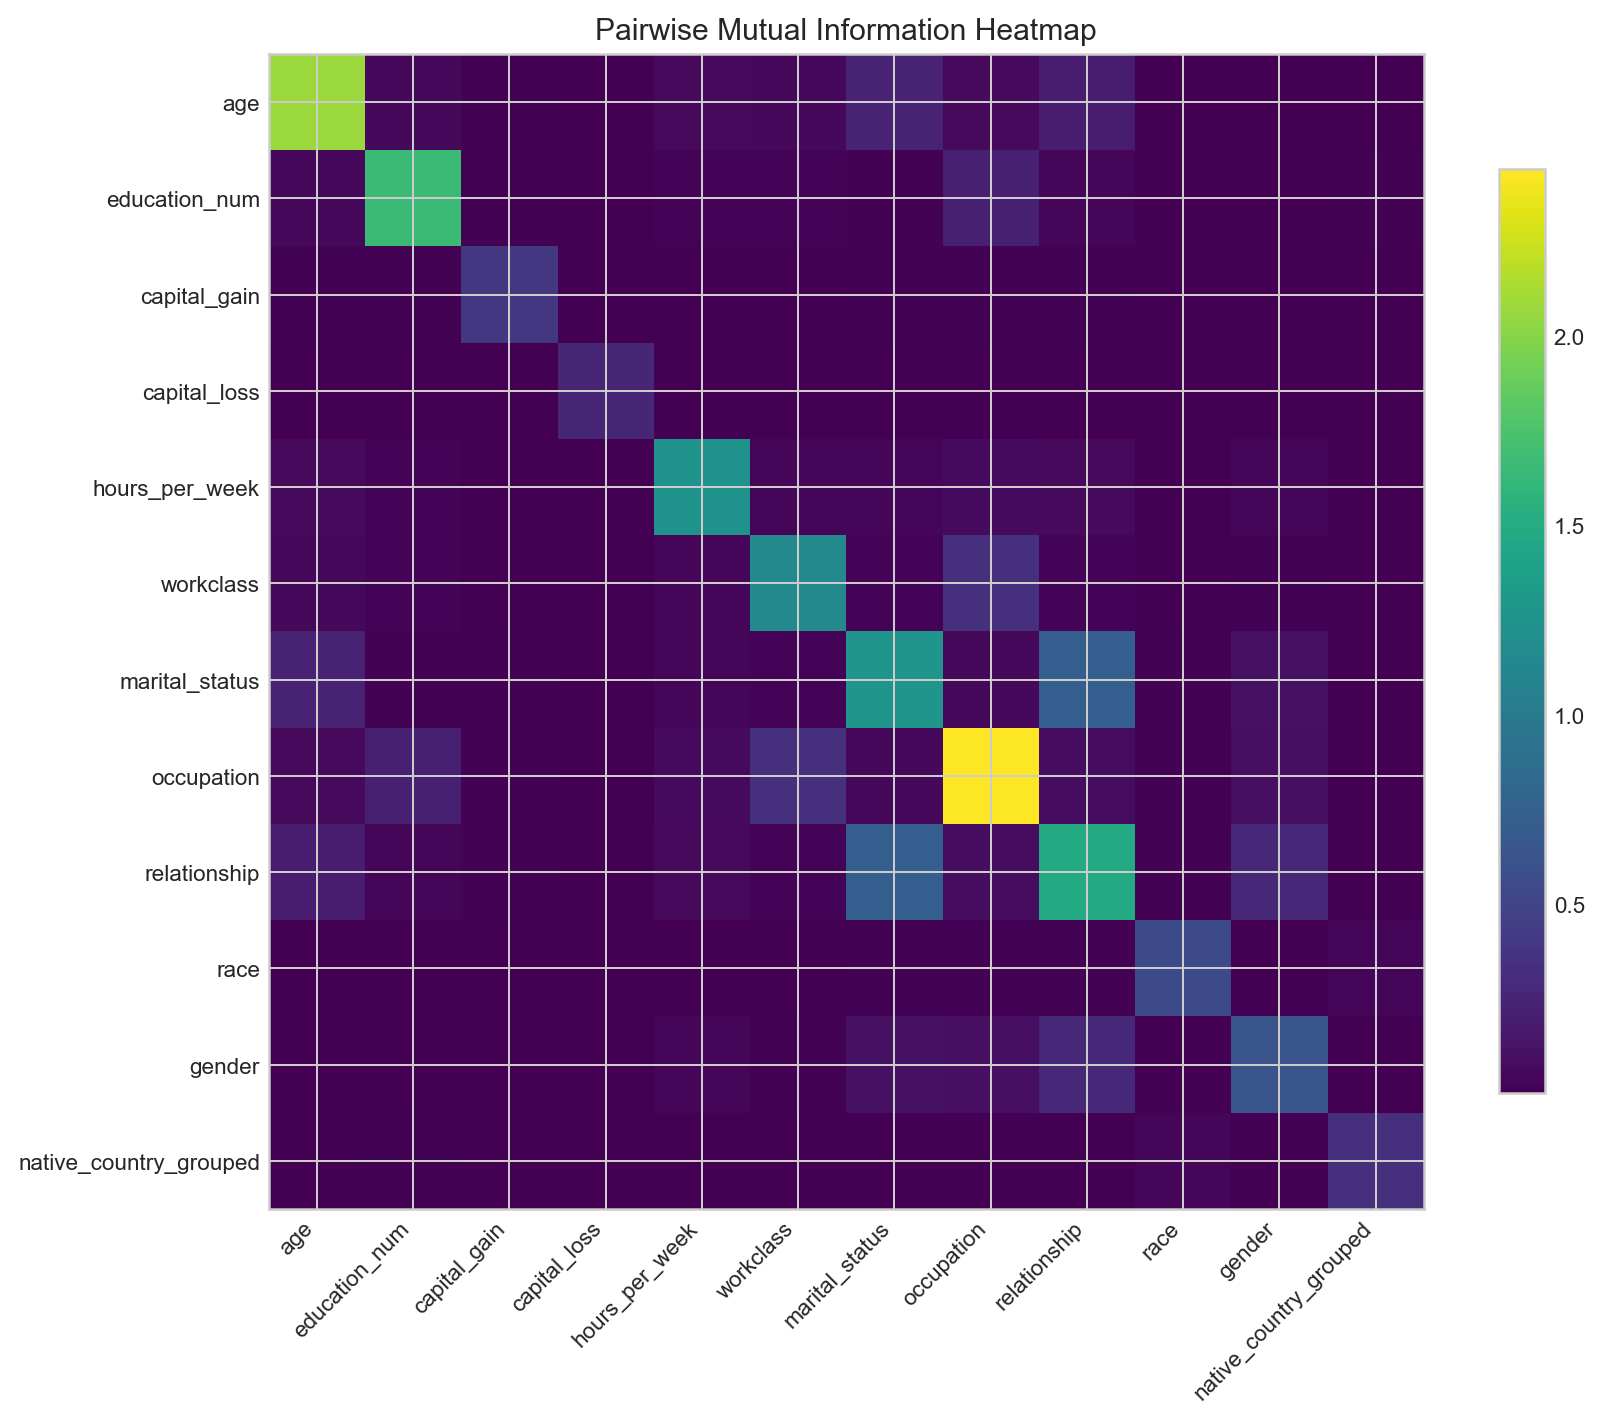

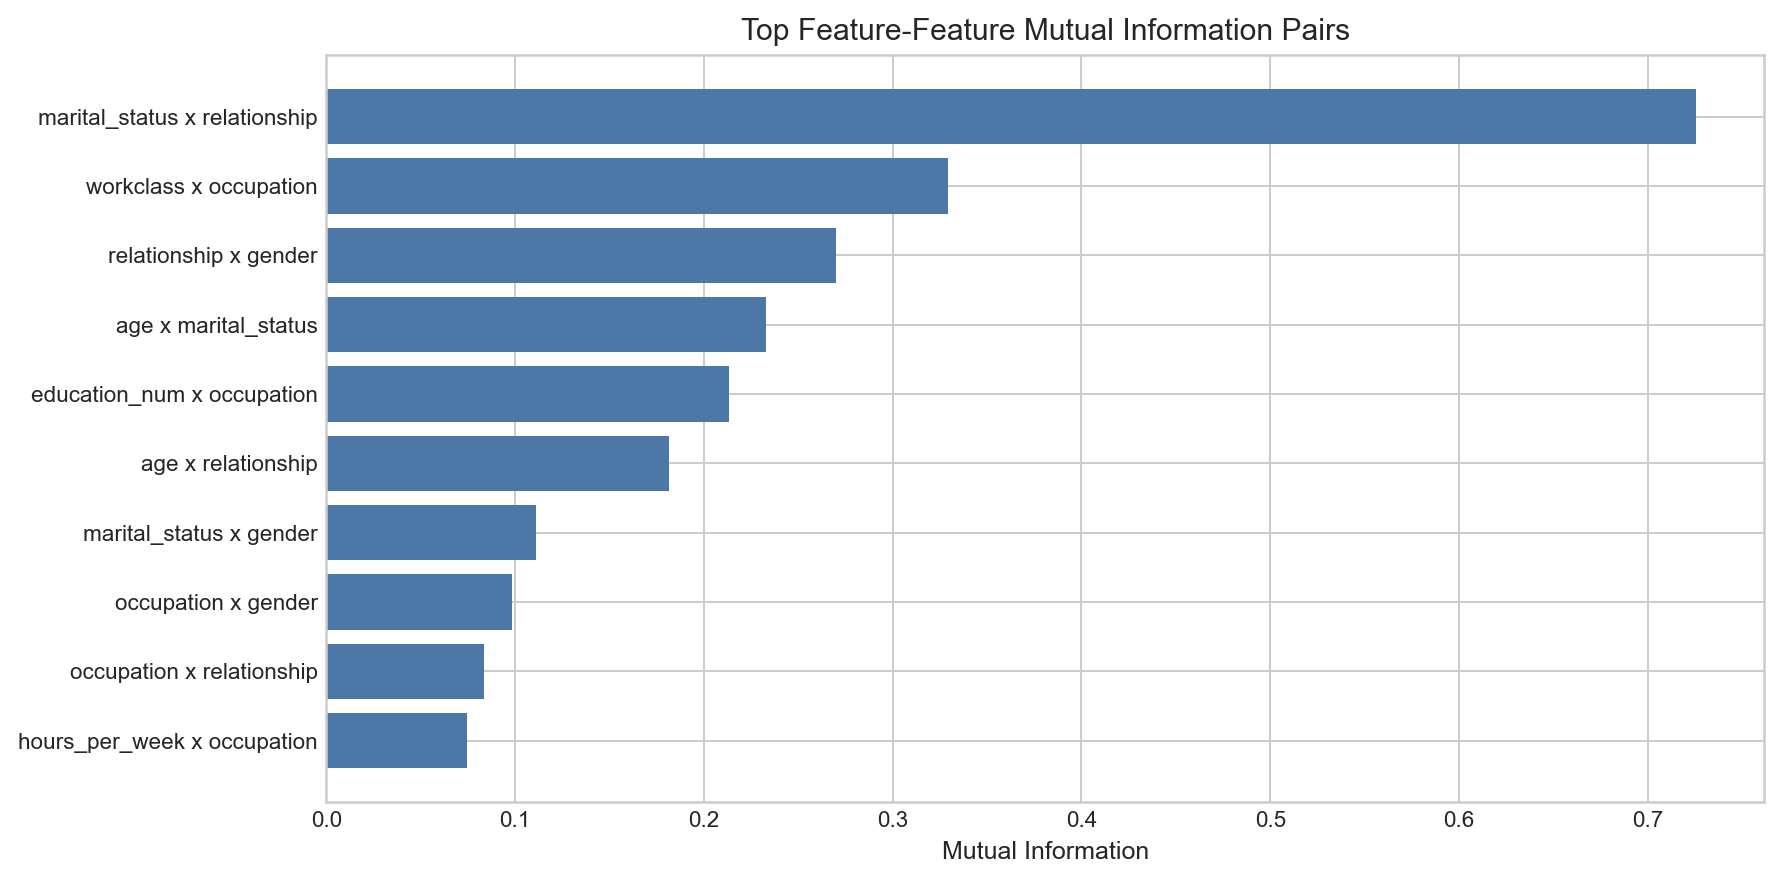

In [6]:

y_train = train_df[config.LABEL_COLUMN]

baseline_rules = fit_binning_rules(train_df, config.MI_BASELINE_BINS)
baseline_discrete = apply_binning_rules(train_df, baseline_rules)
mi_matrix_df, label_df, pairs_df = compute_mi_outputs(baseline_discrete, y_train)
candidate_df = select_candidate_interactions(pairs_df, label_df)

sensitivity_rules = fit_binning_rules(train_df, config.MI_SENSITIVITY_BINS)
sensitivity_discrete = apply_binning_rules(train_df, sensitivity_rules)
_, sensitivity_label_df, sensitivity_pairs_df = compute_mi_outputs(sensitivity_discrete, y_train)
sensitivity_candidate_df = select_candidate_interactions(sensitivity_pairs_df, sensitivity_label_df)

save_dataframe(mi_matrix_df.reset_index().rename(columns={"index": "feature"}), config.TABLES_DIR / "mi_matrix.csv")
save_dataframe(label_df, config.TABLES_DIR / "feature_label_mi.csv")
save_dataframe(pairs_df.head(20), config.TABLES_DIR / "top_feature_pairs.csv")
save_dataframe(candidate_df, config.TABLES_DIR / "candidate_interactions.csv")
save_dataframe(sensitivity_pairs_df.head(20), config.TABLES_DIR / "top_feature_pairs_sensitivity.csv")
save_dataframe(sensitivity_candidate_df, config.TABLES_DIR / "candidate_interactions_sensitivity.csv")

plot_mi_heatmap(mi_matrix_df, config.FIGURES_DIR / "mi_heatmap.png")
plot_top_pairs(pairs_df, config.FIGURES_DIR / "top_mi_pairs.png")
plot_feature_label_ranking(label_df, config.FIGURES_DIR / "feature_label_mi_ranking.png")

mi_summary = mi_sensitivity_overlap(
    pairs_df,
    sensitivity_pairs_df,
    candidate_df,
    sensitivity_candidate_df,
)
mi_summary_df = pd.DataFrame(
    [
        {
            "summary_type": "top_pair_overlap",
            "overlap_count": mi_summary["top_overlap_count"],
            "union_count": mi_summary["top_union_count"],
            "pairs": ", ".join(mi_summary["top_overlap_pairs"]),
        },
        {
            "summary_type": "candidate_overlap",
            "overlap_count": mi_summary["candidate_overlap_count"],
            "union_count": mi_summary["candidate_union_count"],
            "pairs": ", ".join(mi_summary["candidate_overlap_pairs"]),
        },
    ]
)
save_dataframe(mi_summary_df, config.TABLES_DIR / "mi_sensitivity_summary.csv")

show_table(mi_summary_df, rows=len(mi_summary_df))
show_table(label_df)
show_table(pairs_df, rows=10)
show_table(candidate_df)
show_image(config.FIGURES_DIR / "mi_heatmap.png")
show_image(config.FIGURES_DIR / "top_mi_pairs.png")


## Sparse Logistic Signal

An L1-regularized logistic model gives a compact baseline here and shows which feature groups still carry signal after regularization has done its work.


,C,mean_cv_accuracy,std_cv_accuracy,mean_cv_precision,std_cv_precision,mean_cv_recall,std_cv_recall,mean_cv_f1,std_cv_f1,mean_cv_roc_auc,std_cv_roc_auc
0,0.001000,0.823766,0.002304,0.783743,0.008060,0.363890,0.010956,0.496914,0.010598,0.886536,0.002032
1,0.003162,0.836614,0.003228,0.724617,0.008106,0.511500,0.010044,0.599664,0.009313,0.889169,0.001983
2,0.010000,0.839147,0.002855,0.714284,0.005280,0.546156,0.012066,0.618959,0.009275,0.893000,0.001915
3,0.031620,0.843856,0.002668,0.718419,0.003716,0.571293,0.013153,0.636400,0.009243,0.898769,0.001977
4,0.100000,0.844906,0.002548,0.715961,0.004783,0.583166,0.012930,0.642702,0.008632,0.899822,0.002260


,feature_group,nonzero_count,nonzero_share,mean_total_abs_coefficient,max_total_abs_coefficient
6,marital_status,9,1.0,3.358503,5.481468
3,education_num,9,1.0,0.741373,0.800412
1,capital_gain_log1p,9,1.0,0.474560,0.508105
5,hours_per_week,9,1.0,0.328174,0.354702
0,age,9,1.0,0.317155,0.349384


,accuracy,precision,recall,f1,roc_auc,C
0,0.847681,0.723449,0.588537,0.649057,0.897469,1.0


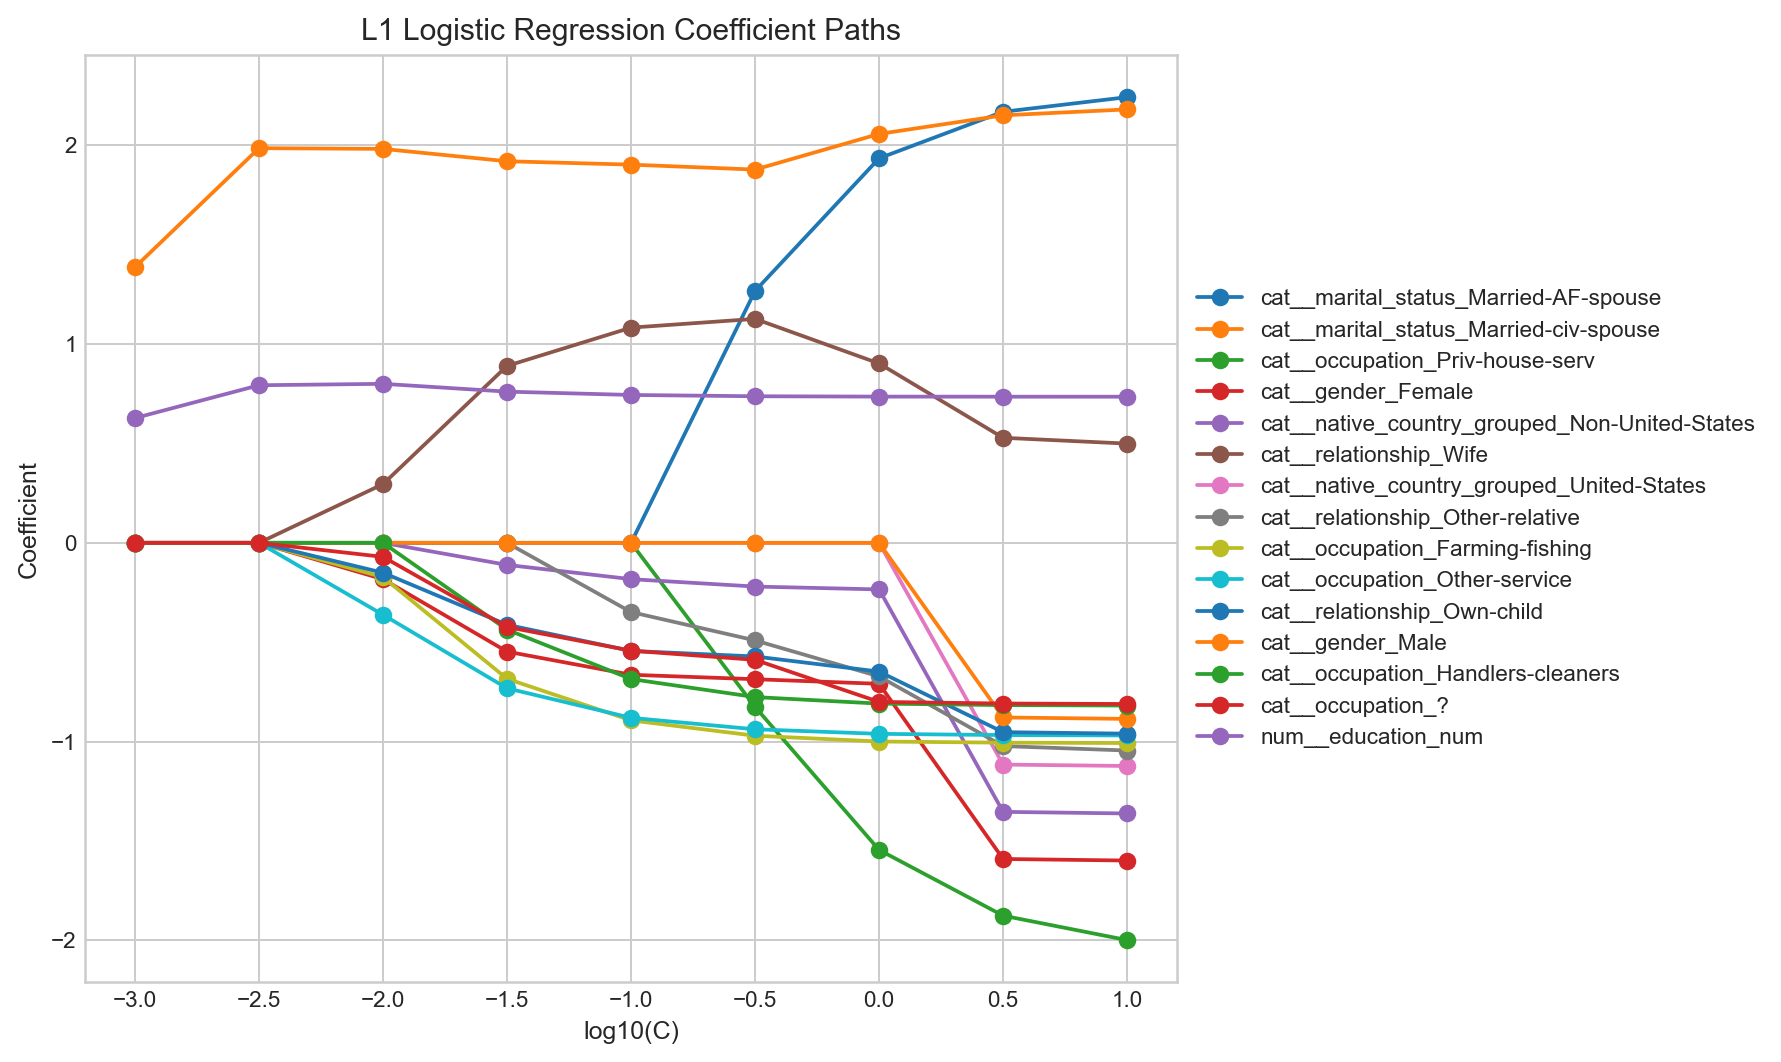

In [7]:
X_train = train_df[config.MODEL_BASE_FEATURES]
X_test = test_df[config.MODEL_BASE_FEATURES]
y_test = test_df[config.LABEL_COLUMN]

cv_summary_df = cross_validate_logistic(X_train, y_train)
coefficient_df, group_df = fit_logistic_and_extract_coefficients(X_train, y_train)
group_stability_df = feature_group_stability_table(group_df)
best_c = choose_best_c(cv_summary_df)
baseline_metrics, _ = evaluate_logistic_model(X_train, y_train, X_test, y_test, c_value=best_c)
baseline_metrics_df = pd.DataFrame([baseline_metrics])

save_dataframe(cv_summary_df, config.METRICS_DIR / "logistic_cv_summary.csv")
save_dataframe(coefficient_df, config.TABLES_DIR / "coefficient_path.csv")
save_dataframe(group_stability_df, config.TABLES_DIR / "stable_features_summary.csv")
save_dataframe(baseline_metrics_df, config.METRICS_DIR / "logistic_baseline_metrics.csv")

plot_coefficient_paths(coefficient_df, config.FIGURES_DIR / "logistic_coefficient_paths.png")

show_table(cv_summary_df)
show_table(group_stability_df)
show_table(baseline_metrics_df)
show_image(config.FIGURES_DIR / "logistic_coefficient_paths.png")


## Interaction Validation

With the baseline in place, we test whether the interaction terms suggested by the MI screen actually improve on the main-effects logistic model.


,feature_a,feature_b,selection_source,pairwise_mi,delta_cv_roc_auc,delta_test_roc_auc,evidence_code
0,age,hours_per_week,mi_top_pair,0.065720,0.000174,0.000210,unstable
1,age,education_num,mi_top_pair,0.051702,-0.000026,-0.000012,unstable
2,education_num,hours_per_week,mi_top_pair,0.026485,-0.000043,-0.000003,unstable
3,education_num,capital_gain,mi_top_pair,0.015962,-0.000025,0.000057,unstable
4,capital_gain,hours_per_week,domain_plausibility_reserve,0.007698,0.000042,-0.000066,unstable


,model,accuracy,precision,recall,f1,roc_auc,C,interaction_count,selected_interactions
0,baseline_main_effects,0.847681,0.723449,0.588537,0.649057,0.897469,1.0,0,
1,interaction_augmented,NaN,NaN,NaN,NaN,NaN,1.0,0,


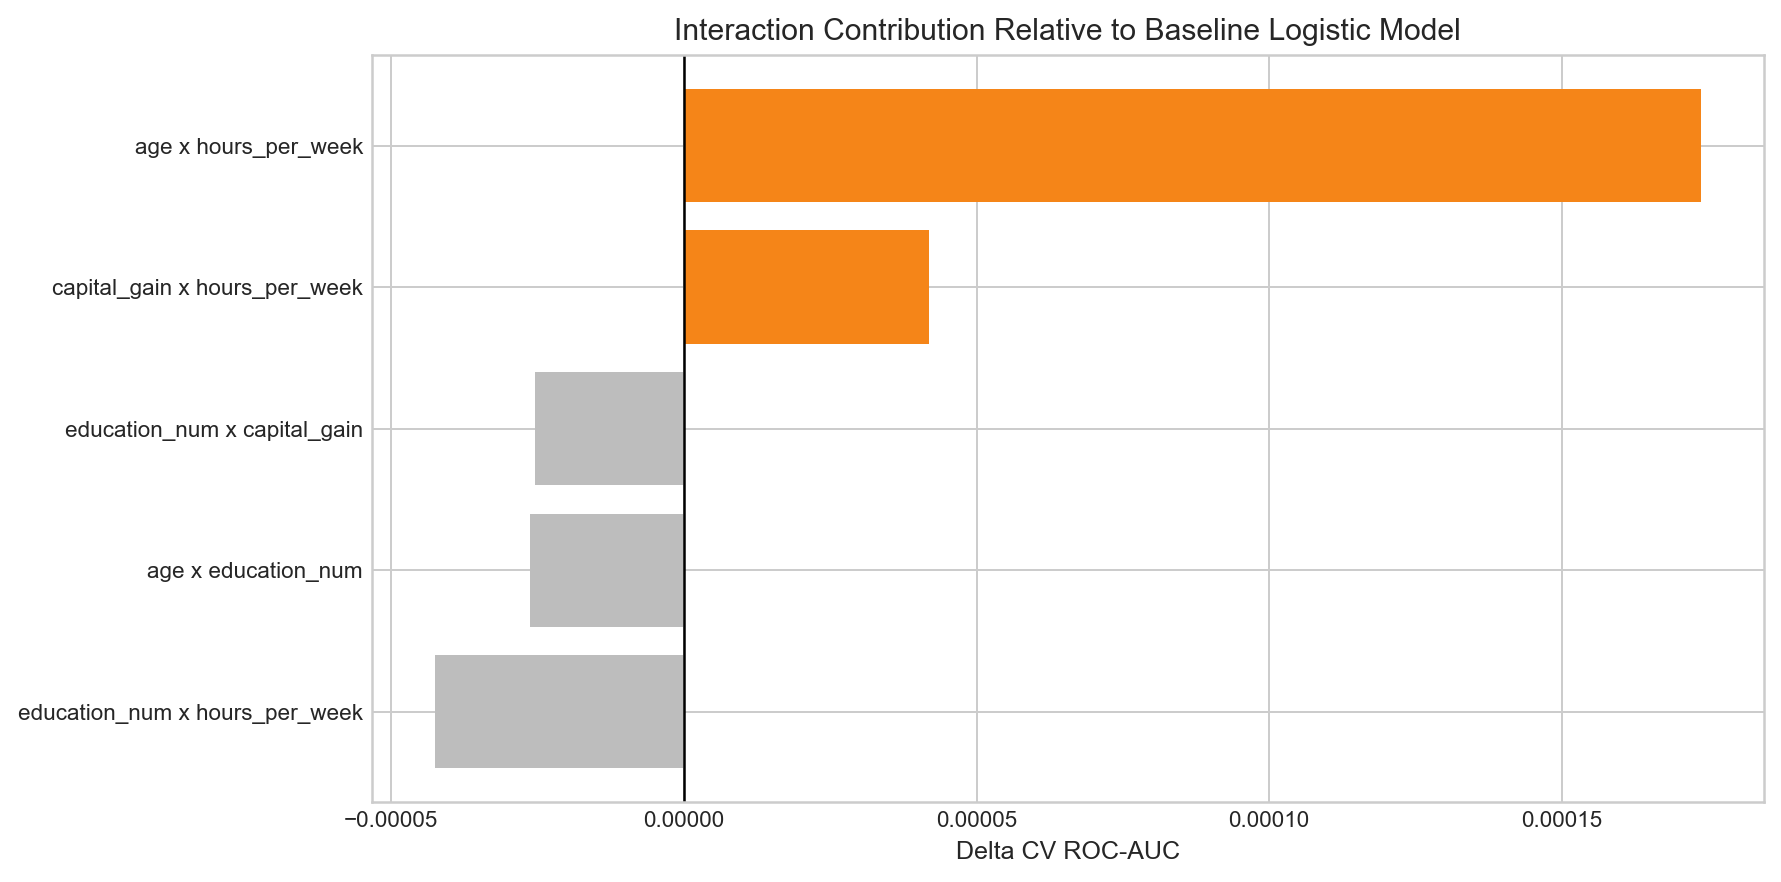

In [8]:
baseline_best_row = cv_summary_df.sort_values(["mean_cv_roc_auc", "C"], ascending=[False, True]).iloc[0]
baseline_best_c = float(baseline_best_row["C"])
baseline_cv_auc = float(baseline_best_row["mean_cv_roc_auc"])
baseline_test_auc = float(baseline_metrics["roc_auc"])

tested_df, survival_df, survivor_pairs, combined_best_c, combined_metrics = evaluate_interaction_candidates(
    train_df,
    test_df,
    candidate_df,
    baseline_best_c=baseline_best_c,
    baseline_cv_auc=baseline_cv_auc,
    baseline_test_auc=baseline_test_auc,
)
interaction_metrics_df = interaction_model_metrics_table(baseline_metrics, combined_metrics, survivor_pairs)
evidence_df = tested_df[
    [
        "feature_a",
        "feature_b",
        "selection_source",
        "pairwise_mi",
        "delta_cv_roc_auc",
        "delta_test_roc_auc",
        "evidence_code",
    ]
].copy()

save_dataframe(tested_df, config.TABLES_DIR / "tested_interactions.csv")
save_dataframe(survival_df, config.TABLES_DIR / "interaction_survival_summary.csv")
save_dataframe(evidence_df, config.TABLES_DIR / "interaction_evidence_table.csv")
save_dataframe(interaction_metrics_df, config.METRICS_DIR / "interaction_model_metrics.csv")

plot_interaction_delta_auc(tested_df, config.FIGURES_DIR / "interaction_delta_cv_auc.png")

show_table(evidence_df)
show_table(interaction_metrics_df)
show_image(config.FIGURES_DIR / "interaction_delta_cv_auc.png")


## SVM Boundary Analysis

We then compare linear and nonlinear SVM variants on the same split to see whether the decision boundary looks mostly linear or whether a kernel buys us something meaningful.


,family,params,mean_cv_roc_auc,std_cv_roc_auc,mean_cv_f1,std_cv_f1
0,linear,{'C': 0.1},0.893243,0.003369,0.628269,0.012049
1,linear,{'C': 10.0},0.893205,0.003546,0.629085,0.012548
2,linear,{'C': 1.0},0.893195,0.003507,0.628574,0.012559
3,poly,"{'C': 1.0, 'degree': 2, 'gamma': 'scale', 'coe...",0.897515,0.003775,0.644407,0.006652
4,poly,"{'C': 0.3, 'degree': 2, 'gamma': 'scale', 'coe...",0.894073,0.003683,0.622421,0.003979


,family,params,best_cv_roc_auc,accuracy,precision,recall,f1,roc_auc
0,poly,"{'C': 1.0, 'degree': 2, 'gamma': 'scale', 'coe...",0.897515,0.857406,0.751464,0.603935,0.669670,0.905051
1,linear,{'C': 0.1},0.893243,0.846863,0.726101,0.578272,0.643810,0.897269
2,rbf,"{'C': 3.0, 'gamma': 0.05}",0.892339,0.857406,0.750929,0.604790,0.669983,0.896474


,model,accuracy,precision,recall,f1,roc_auc,C,interaction_count,selected_interactions,params,best_cv_roc_auc
0,logistic_baseline,0.847681,0.723449,0.588537,0.649057,0.897469,1.0,NaN,NaN,NaN,NaN
1,baseline_main_effects,0.847681,0.723449,0.588537,0.649057,0.897469,1.0,0.0,,NaN,NaN
2,interaction_augmented,NaN,NaN,NaN,NaN,NaN,1.0,0.0,,NaN,NaN
3,svm_poly,0.857406,0.751464,0.603935,0.669670,0.905051,NaN,NaN,NaN,"{'C': 1.0, 'degree': 2, 'gamma': 'scale', 'coe...",0.897515
4,svm_linear,0.846863,0.726101,0.578272,0.643810,0.897269,NaN,NaN,NaN,{'C': 0.1},0.893243


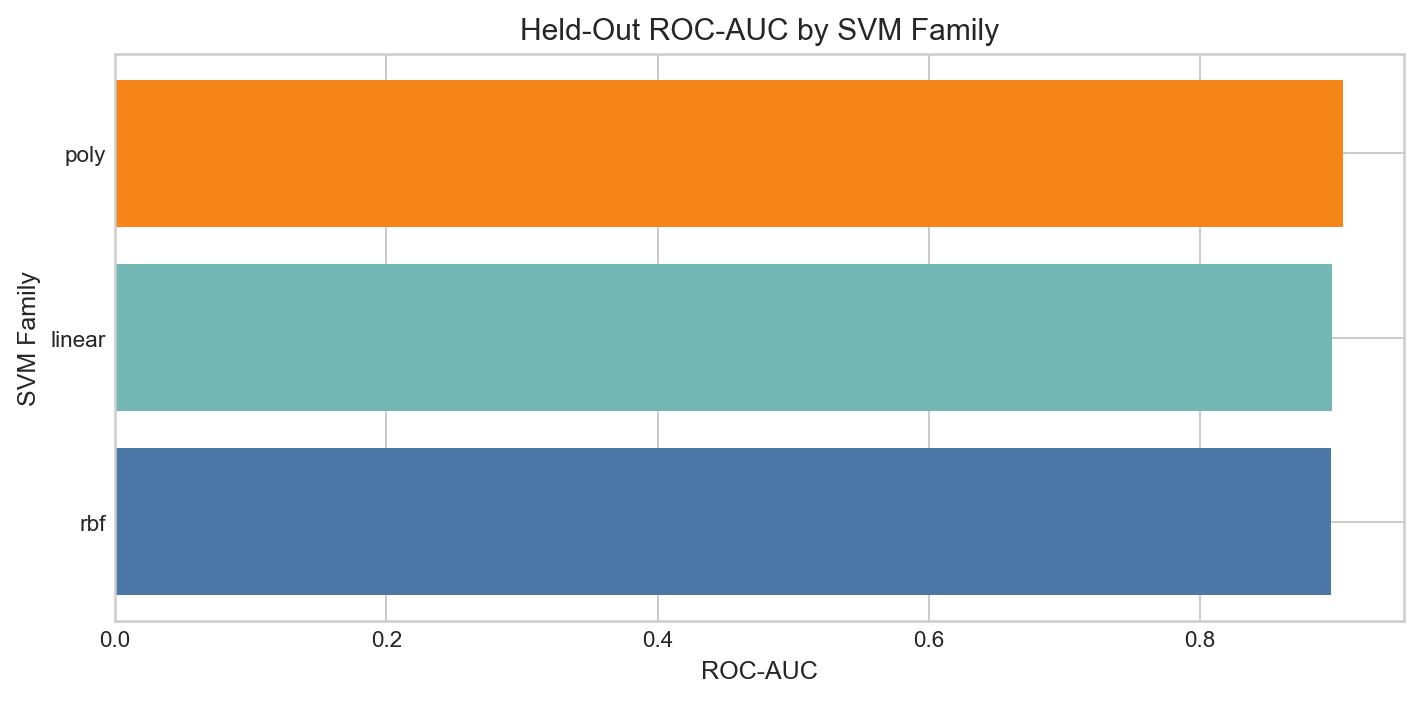

In [9]:
tuning_df, comparison_df = tune_and_evaluate_svm_models(train_df, test_df)
final_model_df = build_final_model_comparison(baseline_metrics_df, interaction_metrics_df, comparison_df)

save_dataframe(tuning_df, config.TABLES_DIR / "svm_tuning_summary.csv")
save_dataframe(comparison_df, config.METRICS_DIR / "svm_comparison.csv")
save_dataframe(final_model_df, config.TABLES_DIR / "final_model_comparison_table.csv")

plot_svm_kernel_comparison(comparison_df, config.FIGURES_DIR / "svm_kernel_comparison.png")

show_table(tuning_df)
show_table(comparison_df)
show_table(final_model_df)
show_image(config.FIGURES_DIR / "svm_kernel_comparison.png")


## Robustness

The last section reruns the main models across the predefined robustness seeds so we can check whether the headline results stay stable instead of leaning on one lucky split.


,feature_group,seed_count
0,occupation,3
1,marital_status,3
2,relationship,3
3,workclass,3
4,race,2
5,education_num,1


,model,min,max
0,logistic_l1,0.897469,0.901428
1,svm_linear,0.897269,0.901436
2,svm_poly,0.905051,0.906406


,linear_model,nonlinear_model,positive_delta_seeds,negative_delta_seeds,zero_delta_seeds,directionally_consistent
0,svm_linear,svm_poly,3,0,0,True


,summary_type,overlap_count,union_count,pairs
0,top_pair_overlap,10,10,"age x marital_status, age x relationship, educ..."
1,candidate_overlap,5,5,"age x education_num, age x hours_per_week, cap..."


,seed,model,accuracy,precision,recall,f1,roc_auc,C
0,7,logistic_l1,0.847989,0.721328,0.594525,0.651817,0.900594,1.0
1,7,svm_linear,0.848807,0.725984,0.591531,0.651897,0.900102,NaN
2,7,svm_poly,0.856382,0.748803,0.601796,0.667299,0.906406,NaN
3,42,logistic_l1,0.847681,0.723449,0.588537,0.649057,0.897469,1.0
4,42,svm_linear,0.846863,0.726101,0.578272,0.643810,0.897269,NaN
5,42,svm_poly,0.857406,0.751464,0.603935,0.669670,0.905051,NaN
6,99,logistic_l1,0.845327,0.714805,0.588537,0.645555,0.901428,1.0
7,99,svm_linear,0.847579,0.725678,0.583832,0.647073,0.901436,NaN
8,99,svm_poly,0.854028,0.741525,0.598802,0.662565,0.905983,NaN


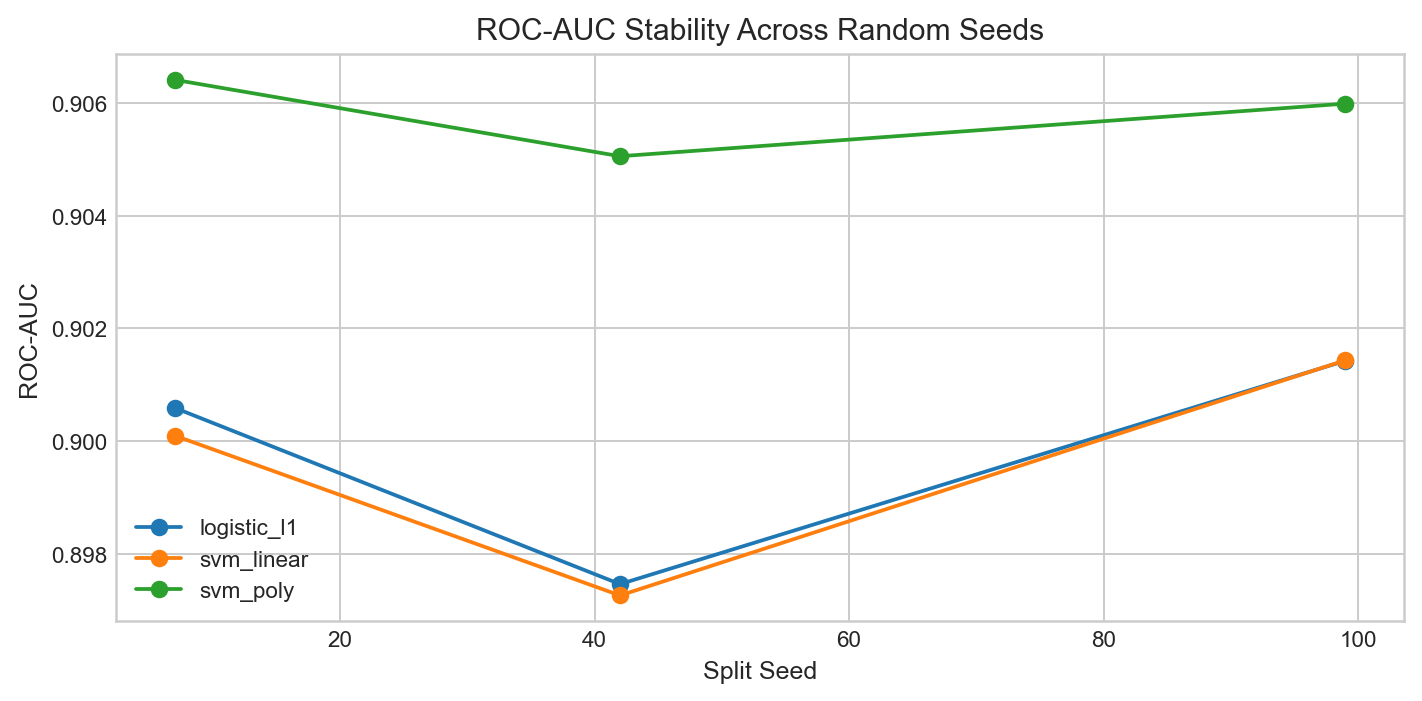

In [10]:
linear_row = comparison_df.loc[comparison_df["family"] == "linear"].iloc[0]
linear_params = ast.literal_eval(linear_row["params"])

nonlinear_candidates = comparison_df[comparison_df["family"].isin(["poly", "rbf"])].sort_values(
    "best_cv_roc_auc", ascending=False
)
nonlinear_row = nonlinear_candidates.iloc[0]
nonlinear_family = nonlinear_row["family"]
nonlinear_params = ast.literal_eval(nonlinear_row["params"])

robustness_df, top_feature_groups = run_robustness_checks(
    analysis_df,
    baseline_best_c=baseline_best_c,
    linear_params=linear_params,
    nonlinear_family=nonlinear_family,
    nonlinear_params=nonlinear_params,
)

save_dataframe(robustness_df, config.METRICS_DIR / "robustness_summary.csv")
plot_robustness_ranges(robustness_df, config.FIGURES_DIR / "robustness_metric_ranges.png")

feature_group_frequency_df = (
    pd.Series(group for groups in top_feature_groups.values() for group in groups)
    .value_counts()
    .rename_axis("feature_group")
    .reset_index(name="seed_count")
)
robustness_ranges_df = robustness_df.groupby("model")["roc_auc"].agg(["min", "max"]).reset_index()
boundary_consistency_df = pd.DataFrame()
nonlinear_model = f"svm_{nonlinear_family}"
boundary_df = robustness_df.pivot(index="seed", columns="model", values="roc_auc").reset_index()
if nonlinear_model in boundary_df.columns and "svm_linear" in boundary_df.columns:
    deltas = boundary_df[nonlinear_model] - boundary_df["svm_linear"]
    boundary_consistency_df = pd.DataFrame(
        [
            {
                "linear_model": "svm_linear",
                "nonlinear_model": nonlinear_model,
                "positive_delta_seeds": int((deltas > 0).sum()),
                "negative_delta_seeds": int((deltas < 0).sum()),
                "zero_delta_seeds": int((deltas == 0).sum()),
                "directionally_consistent": bool((deltas > 0).sum() >= 2 or (deltas < 0).sum() >= 2),
            }
        ]
    )
mi_overlap_df = pd.DataFrame(
    [
        {
            "summary_type": "top_pair_overlap",
            "overlap_count": mi_summary["top_overlap_count"],
            "union_count": mi_summary["top_union_count"],
            "pairs": ", ".join(mi_summary["top_overlap_pairs"]),
        },
        {
            "summary_type": "candidate_overlap",
            "overlap_count": mi_summary["candidate_overlap_count"],
            "union_count": mi_summary["candidate_union_count"],
            "pairs": ", ".join(mi_summary["candidate_overlap_pairs"]),
        },
    ]
)
save_dataframe(feature_group_frequency_df, config.TABLES_DIR / "robust_feature_group_frequency.csv")
save_dataframe(robustness_ranges_df, config.TABLES_DIR / "robustness_metric_ranges.csv")
save_dataframe(mi_overlap_df, config.TABLES_DIR / "robustness_mi_overlap.csv")
if not boundary_consistency_df.empty:
    save_dataframe(boundary_consistency_df, config.TABLES_DIR / "robustness_boundary_consistency.csv")

show_table(feature_group_frequency_df, rows=len(feature_group_frequency_df))
show_table(robustness_ranges_df, rows=len(robustness_ranges_df))
if not boundary_consistency_df.empty:
    show_table(boundary_consistency_df, rows=len(boundary_consistency_df))
show_table(mi_overlap_df, rows=len(mi_overlap_df))
show_table(robustness_df, rows=10)
show_image(config.FIGURES_DIR / "robustness_metric_ranges.png")


In [11]:

final_summary_df = pd.DataFrame(
    [
        {
            "artifact": "top_continuous_feature",
            "value": ranked_df.iloc[0]["feature"],
            "metric": "single_feature_roc_auc",
            "metric_value": ranked_df.iloc[0]["single_feature_roc_auc"],
        },
        {
            "artifact": "top_label_mi_feature",
            "value": label_df.iloc[0]["feature"],
            "metric": "feature_label_mi",
            "metric_value": label_df.iloc[0]["feature_label_mi"],
        },
        {
            "artifact": "top_logistic_feature_group",
            "value": group_stability_df.iloc[0]["feature_group"],
            "metric": "nonzero_share",
            "metric_value": group_stability_df.iloc[0]["nonzero_share"],
        },
        {
            "artifact": "best_svm_family",
            "value": comparison_df.sort_values("roc_auc", ascending=False).iloc[0]["family"],
            "metric": "roc_auc",
            "metric_value": comparison_df.sort_values("roc_auc", ascending=False).iloc[0]["roc_auc"],
        },
    ]
)
save_dataframe(final_summary_df, config.TABLES_DIR / "final_summary_table.csv")
show_table(final_summary_df, rows=len(final_summary_df))


,artifact,value,metric,metric_value
0,top_continuous_feature,education_num,single_feature_roc_auc,0.715573
1,top_label_mi_feature,relationship,feature_label_mi,0.115828
2,top_logistic_feature_group,marital_status,nonzero_share,1.000000
3,best_svm_family,poly,roc_auc,0.905051
